In [ ]:
import pandas as pd
from mlxtend.evaluate import accuracy_score
from sklearn.model_selection import train_test_split, cross_val_score
from xgboost import XGBClassifier
from skopt import BayesSearchCV
from sklearn.metrics import roc_auc_score
import shap
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [ ]:
df = pd.read_csv('E:/3rd year/2nd term/Interpretability/Dsai 305 Project/_Data/cardio_data_cleaned(IQR).csv')
X = df.drop(columns=['cardio'])
y = df['cardio']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
param_space = {
    'n_estimators': (100, 1000),
    'max_depth': (3, 10),
    'learning_rate': (0.01, 0.3),
    'subsample': (0.2, 1.0)
}
opt = BayesSearchCV(
    estimator=xgb,
    search_spaces=param_space,
    scoring='roc_auc',
    n_iter=30,
    cv=5,
    n_jobs=-1,
    verbose=1
)
opt.fit(X_train, y_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

C:\Users\omaar\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [21:08:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


BayesSearchCV(cv=5,
              estimator=XGBClassifier(base_score=None, booster=None,
                                      callbacks=None, colsample_bylevel=None,
                                      colsample_bynode=None,
                                      colsample_bytree=None, device=None,
                                      early_stopping_rounds=None,
                                      enable_categorical=False,
                                      eval_metric='logloss', feature_types=None,
                                      feature_weights=None, gamma=None,
                                      grow_policy=None, importance_type=None,
                                      interaction_constrain...
                                      max_cat_to_onehot=None,
                                      max_delta_step=None, max_depth=None,
                                      max_leaves=None, min_child_weight=None,
                                      missing=nan, monotone_constraints=None,
                                      multi_strategy=None, n_estimators=None,
                                      n_jobs=None, num_parallel_tree=None, ...),
              n_iter=30, n_jobs=-1, scoring='roc_auc',
              search_spaces={'learning_rate': (0.01, 0.3), 'max_depth': (3, 10),
                             'n_estimators': (100, 1000),
                             'subsample': (0.2, 1.0)},
              verbose=1)

In [30]:
best_params = opt.best_params_
print("Optimal Parameters:", best_params)

Optimal Parameters: OrderedDict({'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 1000, 'subsample': 0.23353353533599444})


In [31]:
from sklearn.metrics import accuracy_score

In [32]:
xgb_best = XGBClassifier(**best_params, eval_metric='logloss')
xgb_best.fit(X_train, y_train)
y_pred= xgb_best.predict(X_test)
accuracy=accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy}")

Test Accuracy: 0.726661867050636


In [33]:
from sklearn.metrics import confusion_matrix, f1_score, precision_score

In [34]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
sensitivity1 = tp / (tp + fn)
specificity1 = 1 - (fp / (tn + fp))
f1_1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
y_pred_proba = xgb_best.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, y_pred_proba)
print(
    f"Sensitivity: {sensitivity1}, Specificity: {specificity1}, F1 Score: {f1_1}, Precision: {precision}, AUC Score: {auc_score}")

Sensitivity: 0.6915204678362573, Specificity: 0.7607565011820331, F1 Score: 0.7136032185064118, Precision: 0.7371428571428571, AUC Score: 0.7894704839909656


In [35]:
explainer = shap.TreeExplainer(xgb_best)
shap_values = explainer.shap_values(X_test)

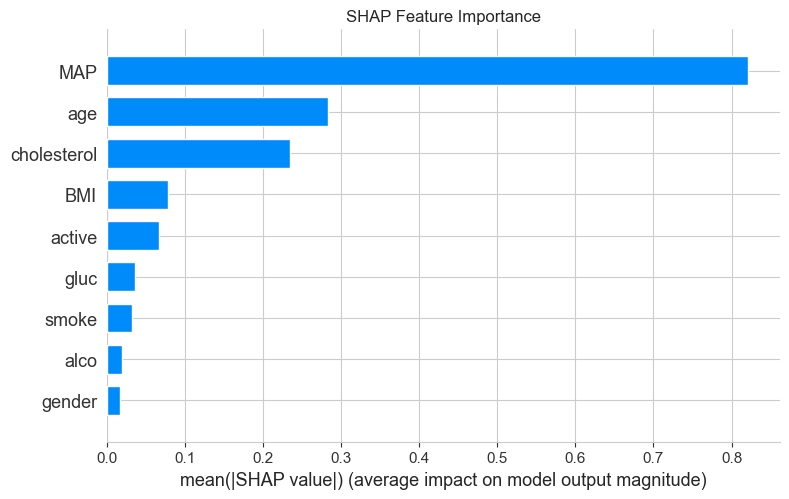

In [36]:
shap.summary_plot(shap_values, X_test, plot_type="bar", feature_names=X_test.columns, show=False)
plt.title("SHAP Feature Importance")
plt.tight_layout()
plt.show()

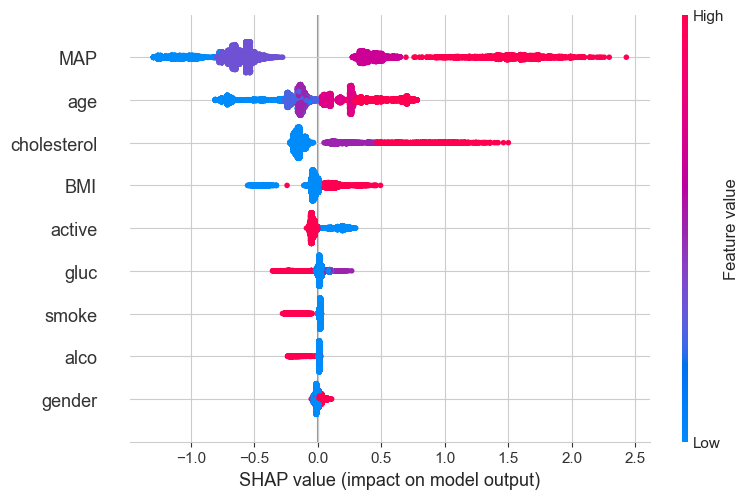

In [37]:
shap.summary_plot(shap_values, X_test)
plt.show()

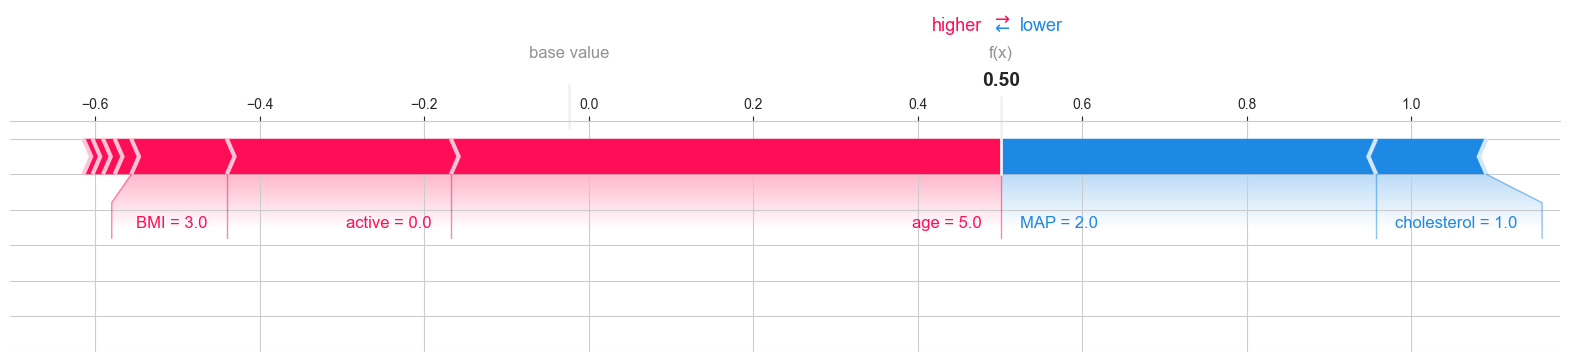

In [38]:
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0], X_test.iloc[0], matplotlib=True)

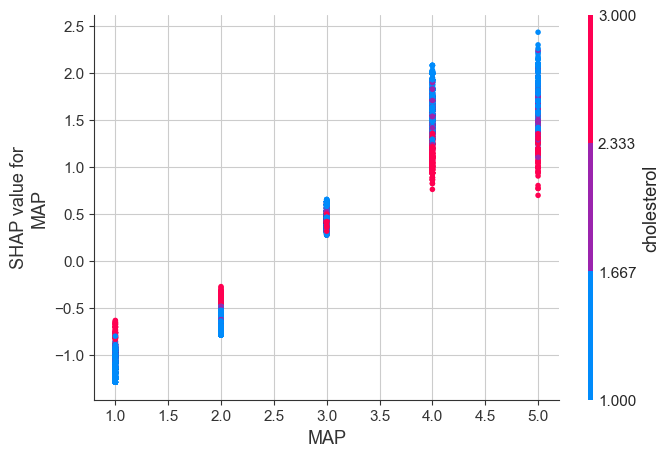

In [39]:
shap.dependence_plot("MAP", shap_values, X_test, interaction_index="cholesterol")

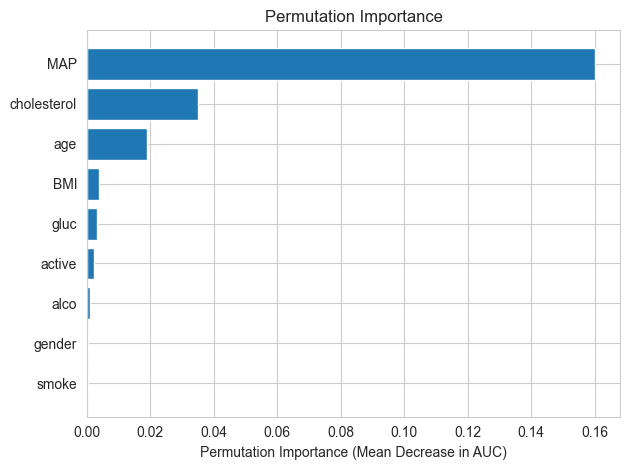

Feature: smoke, Importance: 0.0003 ± 0.0006
Feature: gender, Importance: 0.0004 ± 0.0002
Feature: alco, Importance: 0.0008 ± 0.0005
Feature: active, Importance: 0.0023 ± 0.0007
Feature: gluc, Importance: 0.0031 ± 0.0004
Feature: BMI, Importance: 0.0038 ± 0.0012
Feature: age, Importance: 0.0190 ± 0.0016
Feature: cholesterol, Importance: 0.0351 ± 0.0022
Feature: MAP, Importance: 0.1600 ± 0.0034


In [40]:
perm_importance = permutation_importance(xgb_best, X_test, y_test, n_repeats=10)
sorted_idx = perm_importance.importances_mean.argsort()
plt.barh(X_test.columns[sorted_idx], perm_importance.importances_mean[sorted_idx])
plt.xlabel("Permutation Importance (Mean Decrease in AUC)")
plt.title("Permutation Importance")
plt.tight_layout()
plt.show()
for i in sorted_idx:
    print(f"Feature: {X_test.columns[i]}, Importance: {perm_importance.importances_mean[i]:.4f} ± {perm_importance.importances_std[i]:.4f}")

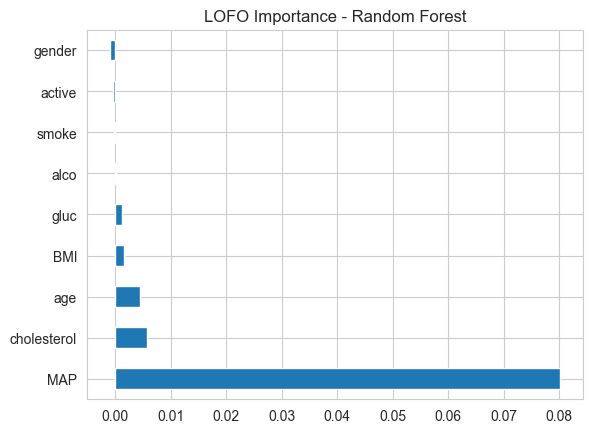

In [41]:
from sklearn.model_selection import cross_val_score
baseline = cross_val_score(xgb_best, X_train, y_train, cv=5).mean()
lofo_scores = {}
for col in X_test.columns:
    X_lofo = X_train.drop(columns=[col])
    score = cross_val_score(xgb_best, X_lofo, y_train, cv=5).mean()
    lofo_scores[col] = baseline - score
lofo_df = pd.Series(lofo_scores).sort_values(ascending=False)
lofo_df.plot(kind='barh')
plt.title("LOFO Importance - Random Forest")
plt.show()

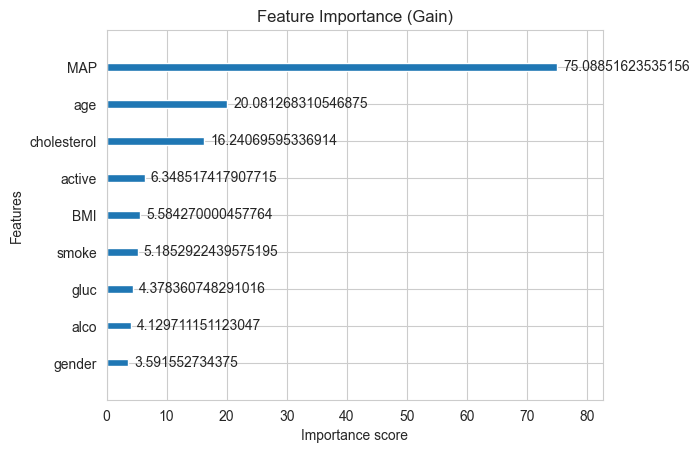

In [42]:
import matplotlib.pyplot as plt
from xgboost import plot_importance
plot_importance(xgb_best, importance_type='gain', max_num_features=10, title="Feature Importance (Gain)")
plt.show()

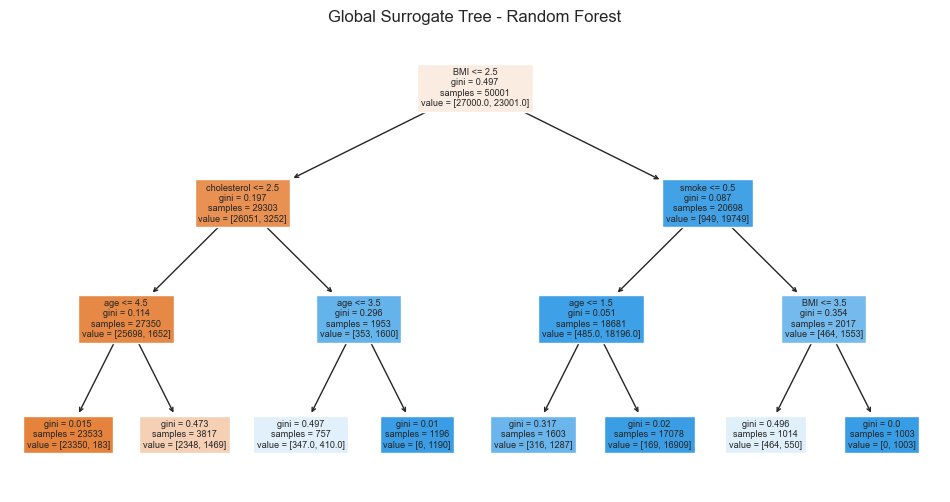

In [53]:
surrogate = DecisionTreeClassifier(max_depth=3)
preds = xgb_best.predict(X_train)
surrogate.fit(X_train, preds)
from sklearn import tree
plt.figure(figsize=(12,6))
tree.plot_tree(surrogate, feature_names=df.columns, filled=True)
plt.title("Global Surrogate Tree - Random Forest")
plt.show()